# Exploratory Data Analysis: Marketing A/B Test

**Dataset**: [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)  
**Goal**: Compare frequentist and Bayesian approaches to analyzing this A/B test, including how each handles sequential monitoring ("peeking").

**Groups**:
- `ad`: users shown the marketing ad (564,577 users)
- `psa`: control group shown a public service announcement instead (23,524 users)

**Initial observation**: The `ad` group converts at ~2.55%, vs. ~1.79% for the `psa` group — a meaningful-looking lift on a fairly low base rate, with a notably unbalanced sample size between groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
df.shape

(588101, 7)

In [3]:
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [4]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [6]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


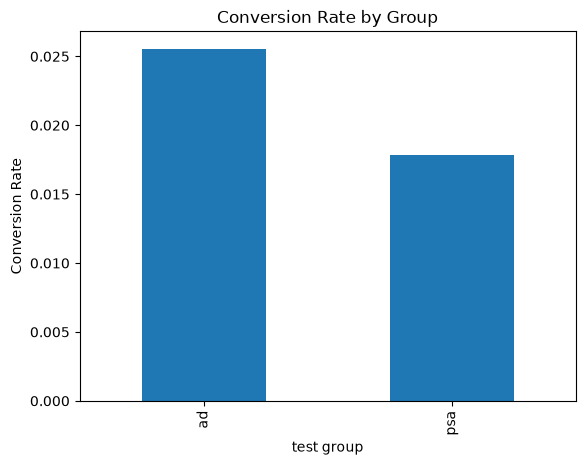

In [7]:
conversion_rates = df.groupby('test group')['converted'].mean()
conversion_rates.plot(kind='bar', title='Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.show()